# CIFAR-10 Convolutional Neural Network (CNN)

This notebook implements image classification on the **CIFAR-10** dataset using a
**Convolutional Neural Network (CNN)**.

## 1. Environment Setup

We use **Keras 3** with the **PyTorch backend**.
Keras 3 is backend-agnostic, so the same model code runs on PyTorch, TensorFlow, or JAX.
PyTorch is chosen here because it gives easy access to CUDA GPU acceleration.

In [57]:
import os

os.environ["KERAS_BACKEND"] = "torch"

import torch
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"Keras version:   {keras.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    print("WARNING: GPU not found – training will be slow on CPU!")

PyTorch version: 2.11.0+cu128
Keras version:   3.12.1
CUDA available:  True


## 2. Load and Explore the Data

CIFAR-10 is built into Keras. We normalise pixel values from **[0, 255]** to **[0.0, 1.0]**.

Unlike the FCN, the CNN keeps images in their original **3-D shape (32, 32, 3)**.
The spatial dimensions are essential — convolutions slide a small filter across height and width
to detect local patterns regardless of position.

In [58]:
from keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train / 255.0
x_test  = x_test  / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"x_train shape: {x_train.shape}  ({x_train.shape[0]} images)")
print(f"x_test  shape: {x_test.shape}")
print(f"Pixel value range: [{x_train.min():.1f}, {x_train.max():.1f}]")

x_train shape: (50000, 32, 32, 3)  (50000 images)
x_test  shape: (10000, 32, 32, 3)
Pixel value range: [0.0, 1.0]


### 2.1 Sample images from each class

Visualising examples helps us understand the task before designing the model.

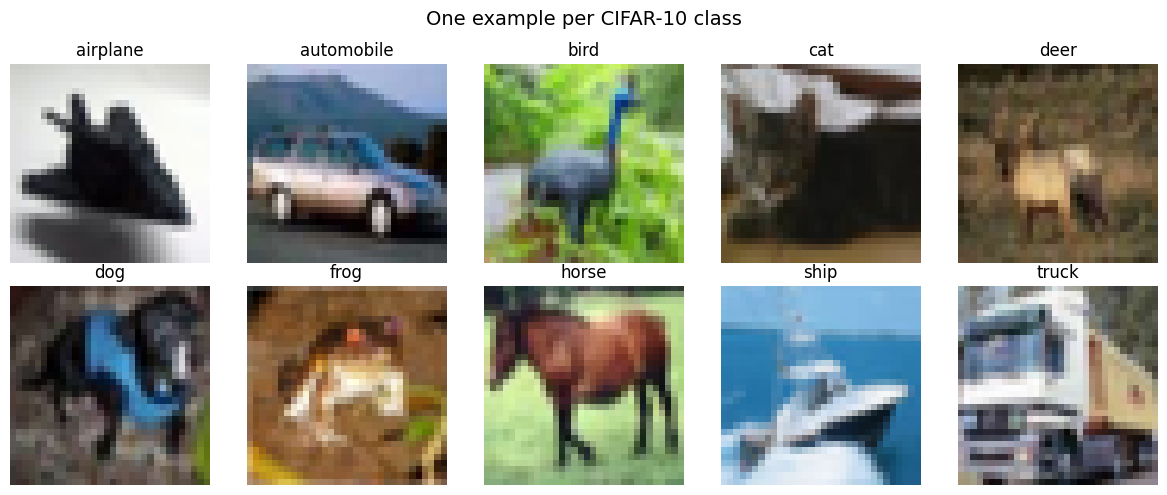

In [59]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('One example per CIFAR-10 class', fontsize=14)

for cls_idx, ax in enumerate(axes.flat):
    sample_idx = np.where(y_train.flatten() == cls_idx)[0][0]
    ax.imshow(x_train[sample_idx])
    ax.set_title(class_names[cls_idx])
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Build the CNN Model



In [60]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),  

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Flatten(),   

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adamw',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,345,066 (5.13 MB)

 Trainable params: 1,343,146 (5.12 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 4. Train the CNN

Same training setup as the FCN for a fair comparison:

10 epochs, batch size 64, 20 % validation split

Despite having fewer parameters, the CNN should reach significantly higher accuracy
because its architecture is well-suited to the structure of image data.

In [61]:
import time

t0 = time.time()
history_cnn = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    verbose=1
)
cnn_train_time = time.time() - t0
print(f"\nTraining time: {cnn_train_time:.1f} s")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.4503 - loss: 1.6563 - val_accuracy: 0.5298 - val_loss: 1.2962
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6198 - loss: 1.0707 - val_accuracy: 0.6753 - val_loss: 0.9397
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6849 - loss: 0.8900 - val_accuracy: 0.6620 - val_loss: 1.0132
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7236 - loss: 0.7841 - val_accuracy: 0.7309 - val_loss: 0.7697
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7516 - loss: 0.7082 - val_accuracy: 0.6955 - val_loss: 0.9033
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.7695 - loss: 0.6544 - val_accuracy: 0.7392 - val_loss: 0.7620
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7901 - loss: 0.6037 - val_accuracy: 0.7716 - val_loss: 0.6782
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8048 - loss: 0.5640 - 

### 4.1 Learning Curves

The CNN's validation curve should stay closer to the training curve than the FCN's,
indicating better generalisation — the architectural inductive biases act as implicit regularisation.

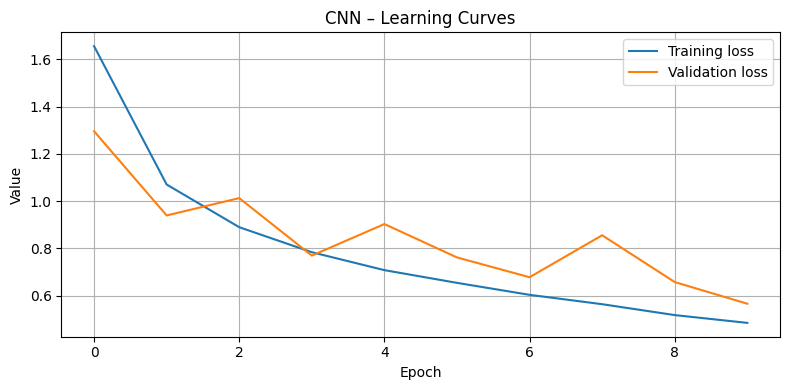

In [62]:
plt.figure(figsize=(8, 4))
plt.plot(history_cnn.history['loss'],      label='Training loss')
plt.plot(history_cnn.history['val_loss'],   label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('CNN – Learning Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 4.2 Test Accuracy

In [63]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nCNN  –  Test loss: {test_loss:.4f}   |   Test accuracy: {test_acc*100:.2f} %")
print(f"Training time: {cnn_train_time:.1f} s")
print(f"Total parameters: {model.count_params():,}")

313/313 - 3s - 10ms/step - accuracy: 0.8094 - loss: 0.5723

CNN  –  Test loss: 0.5723   |   Test accuracy: 80.94 %
Training time: 125.7 s
Total parameters: 1,345,066


## 5. Visualise Predictions

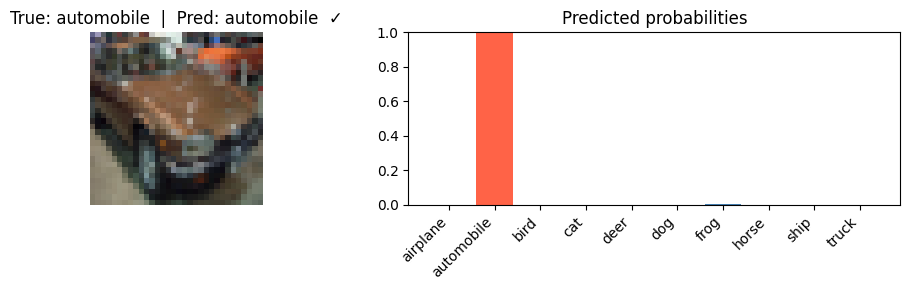

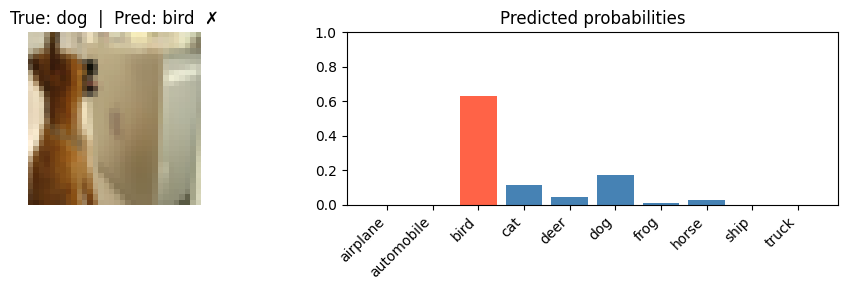

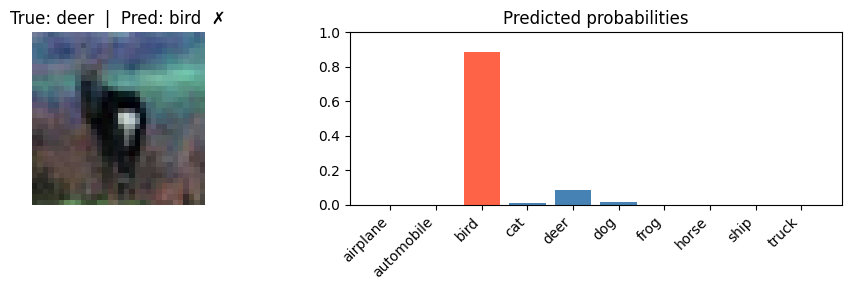

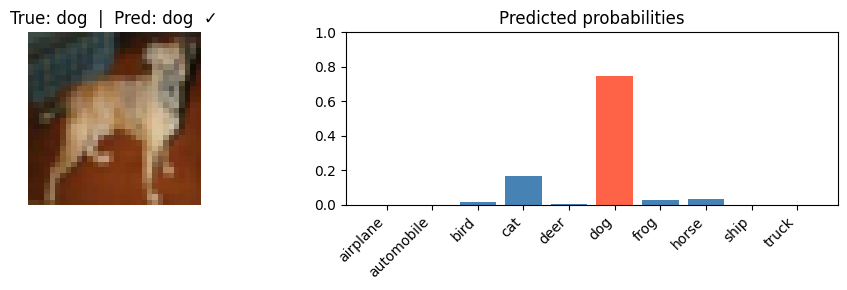

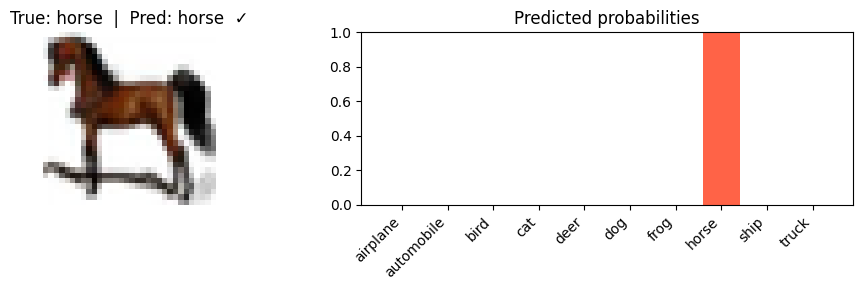

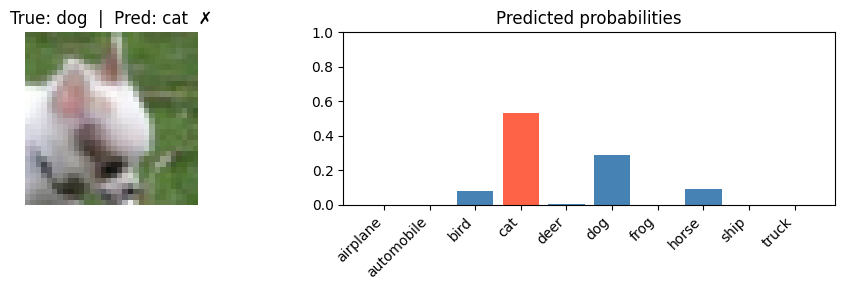

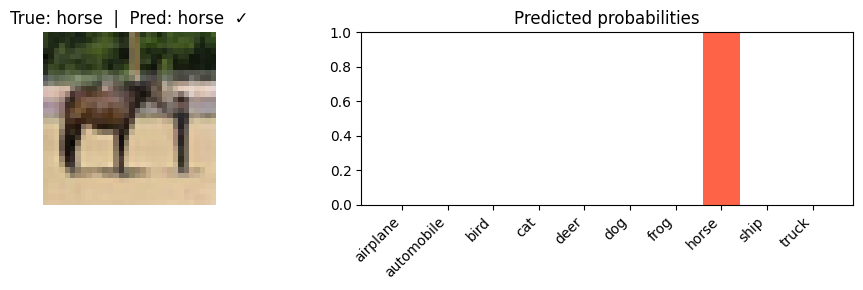

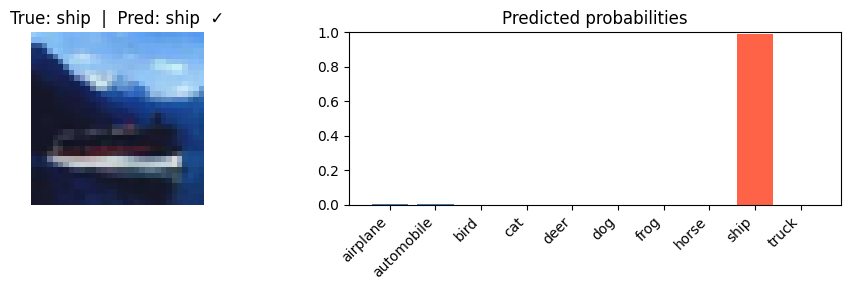

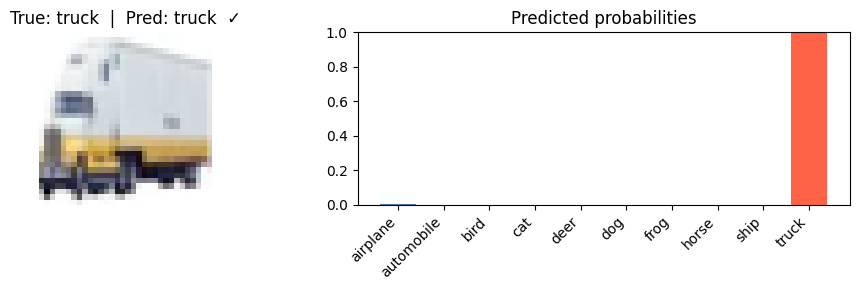

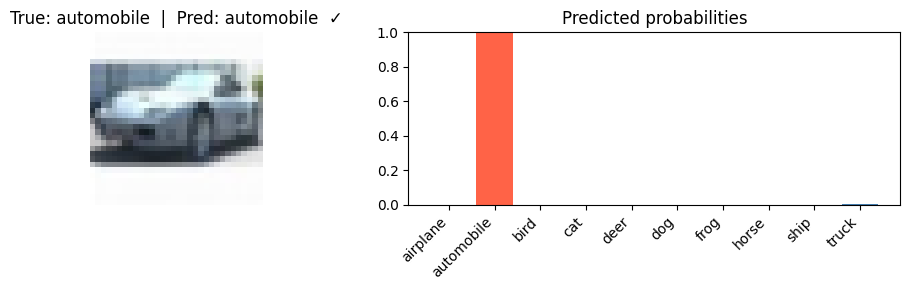

In [64]:
y_pred_cnn = model.predict(x_test, verbose=0)

start = 2000
for k in range(10):
    idx = start + k
    true_label = class_names[y_test[idx][0]]
    pred_label = class_names[np.argmax(y_pred_cnn[idx])]
    correct = '✓' if true_label == pred_label else '✗'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

    ax1.imshow(x_test[idx])
    ax1.set_title(f"True: {true_label}  |  Pred: {pred_label}  {correct}")
    ax1.axis('off')

    colors = ['steelblue'] * 10
    colors[np.argmax(y_pred_cnn[idx])] = 'tomato'
    ax2.bar(range(10), y_pred_cnn[idx], color=colors)
    ax2.set_xticks(range(10))
    ax2.set_xticklabels(class_names, rotation=45, ha='right')
    ax2.set_ylim([0, 1])
    ax2.set_title('Predicted probabilities')

    plt.tight_layout()
    plt.show()

## 6. Analyse Misclassified Images

Total misclassified: 1906 / 10000


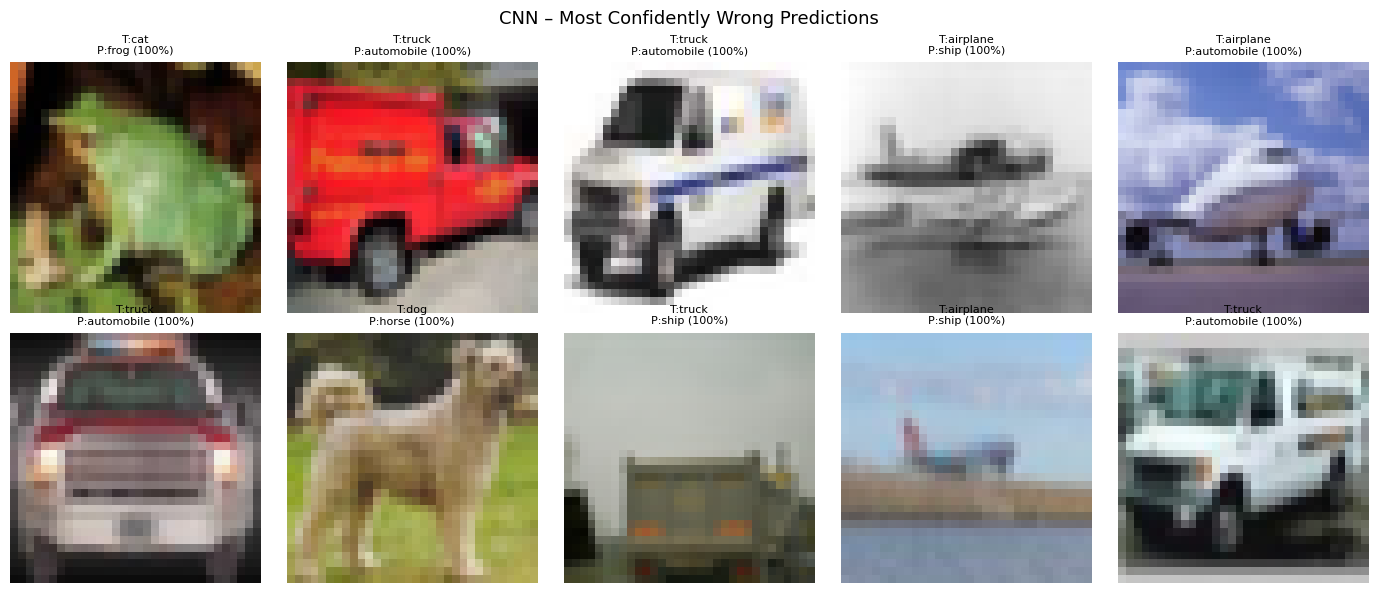

In [65]:
y_true_flat = y_test.flatten()
y_pred_labels = np.argmax(y_pred_cnn, axis=1)

wrong_mask = y_pred_labels != y_true_flat
wrong_indices = np.where(wrong_mask)[0]

confidence_wrong = y_pred_cnn[wrong_indices, y_pred_labels[wrong_indices]]
sorted_order = np.argsort(confidence_wrong)[::-1][:10]
top_wrong = wrong_indices[sorted_order]

print(f"Total misclassified: {wrong_mask.sum()} / {len(y_true_flat)}")

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('CNN – Most Confidently Wrong Predictions', fontsize=13)
for ax, idx in zip(axes.flat, top_wrong):
    ax.imshow(x_test[idx])
    true_cls = class_names[y_true_flat[idx]]
    pred_cls = class_names[y_pred_labels[idx]]
    conf     = confidence_wrong[sorted_order[list(top_wrong).index(idx)]]
    ax.set_title(f"T:{true_cls}\nP:{pred_cls} ({conf:.0%})", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 7. FCN vs CNN Comparison

### Inductive biases
The CNN's superior performance comes from **inductive biases** — assumptions baked into the architecture
that match the structure of natural images:

1. **Locality:** Nearby pixels are more correlated than distant ones. A 3×3 filter exploits this.
2. **Stationarity:** Useful patterns (edges, corners) can appear anywhere. Weight sharing exploits this.
3. **Hierarchy:** Complex features are composed of simpler ones.
   Layer 1 learns edges → Layer 2 learns textures/shapes → Classification head learns object parts.

FCN has none of these biases: it must learn spatial relationships from scratch, requiring far more data
and parameters to achieve comparable accuracy.